# Exploratory Data Analysis

This notebook explores the cleaned `ml-latest` MovieLens data (`data/processed/`) to build intuition
before extending CineIQ's three modeling components: **trend forecasting** (LightGBM), the
**recommendation engine** (Neural Collaborative Filtering), and **RL optimization** (contextual bandit).
The dataset spans 1995 through mid-2023 and includes user-generated **tags** and the **tag genome**
(per-movie relevance scores across ~1,128 descriptive tags), in addition to ratings and movie metadata.
Every section ends with an explicit insight tying what we found back to one or more of the three
components.

In [1]:
%matplotlib inline
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12

PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PALETTE = "mako"


def save_fig(fig, filename):
    path = FIGURES_DIR / filename
    fig.savefig(path, bbox_inches="tight")
    print(f"Saved {path}")

In [2]:
ratings = pd.read_csv(
    PROCESSED_DIR / "ratings_clean.csv",
    dtype={"userId": "int32", "movieId": "int32", "rating": "float32",
           "timestamp": "int64", "year": "int16", "month": "int8"},
)
movies = pd.read_csv(PROCESSED_DIR / "movies_clean.csv")
tags = pd.read_csv(
    PROCESSED_DIR / "tags_clean.csv",
    dtype={"userId": "int32", "movieId": "int32", "timestamp": "int64", "year": "int16", "month": "int8"},
)
links = pd.read_csv(PROCESSED_DIR / "links_clean.csv")
genome_scores = pd.read_csv(
    PROCESSED_DIR / "genome_scores_clean.csv",
    dtype={"movieId": "int32", "tagId": "int16", "relevance": "float32"},
)
genome_tags = pd.read_csv(PROCESSED_DIR / "genome_tags_clean.csv", dtype={"tagId": "int16"})

ratings["date"] = pd.to_datetime(ratings["timestamp"], unit="s")
tags["date"] = pd.to_datetime(tags["timestamp"], unit="s")

for name, df in [("ratings", ratings), ("movies", movies), ("tags", tags),
                  ("links", links), ("genome_scores", genome_scores), ("genome_tags", genome_tags)]:
    print(f"{name}: {df.shape}")

ratings: (33703215, 7)
movies: (86537, 4)
tags: (2328315, 7)
links: (86537, 4)
genome_scores: (18472128, 3)
genome_tags: (1128, 2)


## 1. Dataset Overview

Six files, two different kinds of signal (ratings/tags are events over time; genome scores are a static
per-movie fingerprint). We start by getting the scale and time horizon of each straight before doing
anything else with them.

In [3]:
n_ratings = len(ratings)
n_users = ratings["userId"].nunique()
n_movies_rated = ratings["movieId"].nunique()
n_movies_catalog = movies.shape[0]
n_tags = len(tags)
n_tag_users = tags["userId"].nunique()
n_tagged_movies = tags["movieId"].nunique()
n_genome_movies = genome_scores["movieId"].nunique()
n_genome_tags = genome_tags.shape[0]

date_min, date_max = ratings["date"].min(), ratings["date"].max()
tag_date_min, tag_date_max = tags["date"].min(), tags["date"].max()
span_years = (date_max - date_min).days / 365.25

summary = pd.DataFrame({
    "Metric": [
        "Total ratings", "Ratings date range", "Time span (years)",
        "Unique users (ratings)", "Movies in catalog", "Movies with >= 1 rating",
        "Total tag applications", "Tags date range", "Unique users (tags)", "Movies with >= 1 tag",
        "Movies with genome scores", "Genome tag vocabulary size",
        "Avg. ratings per user", "Avg. ratings per movie",
    ],
    "Value": [
        f"{n_ratings:,}", f"{date_min.date()} to {date_max.date()}", f"{span_years:.1f}",
        f"{n_users:,}", f"{n_movies_catalog:,}", f"{n_movies_rated:,}",
        f"{n_tags:,}", f"{tag_date_min.date()} to {tag_date_max.date()}", f"{n_tag_users:,}", f"{n_tagged_movies:,}",
        f"{n_genome_movies:,}", f"{n_genome_tags:,}",
        f"{n_ratings / n_users:.1f}", f"{n_ratings / n_movies_rated:.1f}",
    ],
})
summary

,Metric,Value
0,Total ratings,"33,703,215"
1,Ratings date range,1995-01-09 to 2023-07-20
2,Time span (years),28.5
3,Unique users (ratings),"307,412"
4,Movies in catalog,"86,537"
5,Movies with >= 1 rating,"43,855"
6,Total tag applications,"2,328,315"
7,Tags date range,2005-12-24 to 2023-07-20
8,Unique users (tags),"25,280"
9,Movies with >= 1 tag,"53,452"


**Insight:** Nearly three decades of ratings history gives the trend forecasting module many
seasons of genre demand to learn from, and the tag genome gives the recommendation engine and the LLM
explanation layer a content-based fingerprint for every scored movie, independent of how many ratings it
has. That's exactly the kind of signal that helps with the cold-start problem sparsity creates (see
Section 10).

## 2. Rating Distribution

How do users use the 0.5-5 star scale — do they rate everything they watch evenly, or mostly the movies
they either loved or hated?

Saved figures\rating_distribution.png


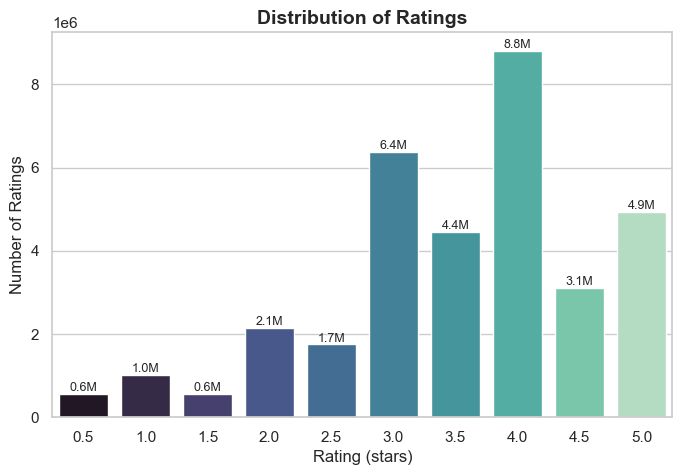

Mean rating: 3.54
Median rating: 4.00
Mode rating: 4.00
% of ratings above 3 stars: 63.2%


In [4]:
rating_counts = ratings["rating"].value_counts().sort_index()
labels = rating_counts.index.astype(str)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=labels, y=rating_counts.values, hue=labels, palette=PALETTE, legend=False, ax=ax)
ax.set_title("Distribution of Ratings")
ax.set_xlabel("Rating (stars)")
ax.set_ylabel("Number of Ratings")
for i, v in enumerate(rating_counts.values):
    ax.text(i, v, f"{v/1e6:.1f}M", ha="center", va="bottom", fontsize=9)
save_fig(fig, "rating_distribution.png")
plt.show()

mean_rating = ratings["rating"].mean()
median_rating = ratings["rating"].median()
mode_rating = ratings["rating"].mode()[0]
pct_above_3 = (ratings["rating"] > 3).mean() * 100

print(f"Mean rating: {mean_rating:.2f}")
print(f"Median rating: {median_rating:.2f}")
print(f"Mode rating: {mode_rating:.2f}")
print(f"% of ratings above 3 stars: {pct_above_3:.1f}%")

**Insight:** The distribution is left-skewed with a mean well above the scale's midpoint — users
are generous raters, largely because rating is voluntary and driven by self-selection (people mostly rate
movies they chose to watch, and chose to watch movies they expected to like). The RL reward threshold and
the recommender's output calibration should both be set against this generous baseline, not a naive 2.5/5
cutoff.

## 3. User Activity Analysis

Who's actually generating this data? A concentrated few power users, or a broad, even base?

Saved figures\user_activity_distribution.png


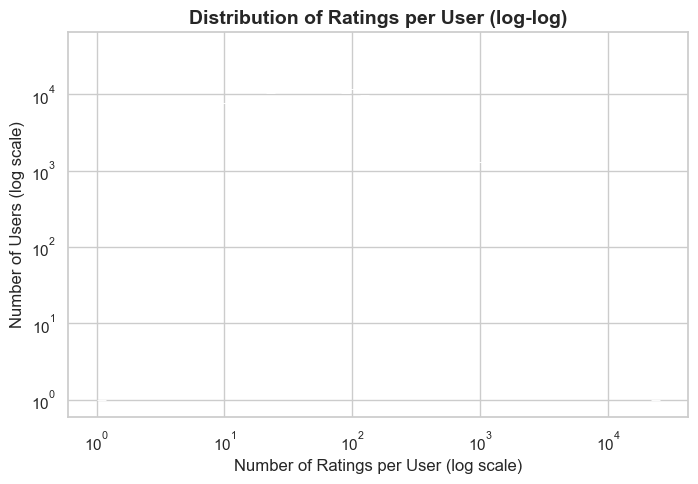

In [5]:
ratings_per_user = ratings.groupby("userId").size().rename("num_ratings")

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(ratings_per_user, bins=60, log_scale=(True, True), color=sns.color_palette(PALETTE, 5)[3], ax=ax)
ax.set_title("Distribution of Ratings per User (log-log)")
ax.set_xlabel("Number of Ratings per User (log scale)")
ax.set_ylabel("Number of Users (log scale)")
save_fig(fig, "user_activity_distribution.png")
plt.show()

Saved figures\user_activity_pareto.png


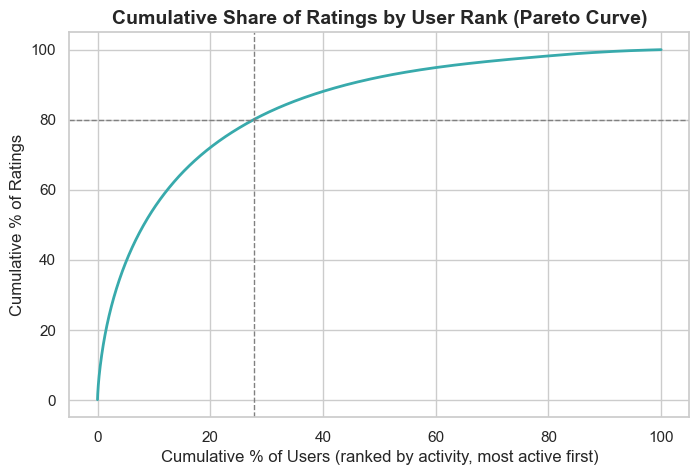

Median ratings per user: 36
Max ratings by a single user: 25,698
27.7% of users account for 80% of all ratings


In [6]:
sorted_counts = ratings_per_user.sort_values(ascending=False)
cum_pct_ratings = sorted_counts.cumsum() / sorted_counts.sum()
cum_pct_users = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)

n_users_for_80pct = int((cum_pct_ratings <= 0.8).sum())
pct_users_for_80pct = n_users_for_80pct / len(sorted_counts) * 100

fig, ax = plt.subplots(figsize=(8, 5))
color = sns.color_palette(PALETTE, 5)[3]
ax.plot(cum_pct_users * 100, cum_pct_ratings * 100, color=color, linewidth=2)
ax.axhline(80, color="gray", linestyle="--", linewidth=1)
ax.axvline(pct_users_for_80pct, color="gray", linestyle="--", linewidth=1)
ax.set_title("Cumulative Share of Ratings by User Rank (Pareto Curve)")
ax.set_xlabel("Cumulative % of Users (ranked by activity, most active first)")
ax.set_ylabel("Cumulative % of Ratings")
save_fig(fig, "user_activity_pareto.png")
plt.show()

print(f"Median ratings per user: {ratings_per_user.median():.0f}")
print(f"Max ratings by a single user: {ratings_per_user.max():,}")
print(f"{pct_users_for_80pct:.1f}% of users account for 80% of all ratings")

**Insight:** Activity concentration follows a Pareto pattern — a small share of power users
drives the large majority of ratings, with a long tail of casual raters. This is the segmentation the RL
contextual bandit should key off of: power users can support aggressive personalization, casual/cold-start
users need exploration-heavy or popularity/genre-prior-based strategies.

## 4. Movie Popularity Analysis

Same concentration question, from the movie side: is attention spread across the ~86K-title catalog, or
concentrated on a small set of blockbusters?

Saved figures\movie_popularity_distribution.png


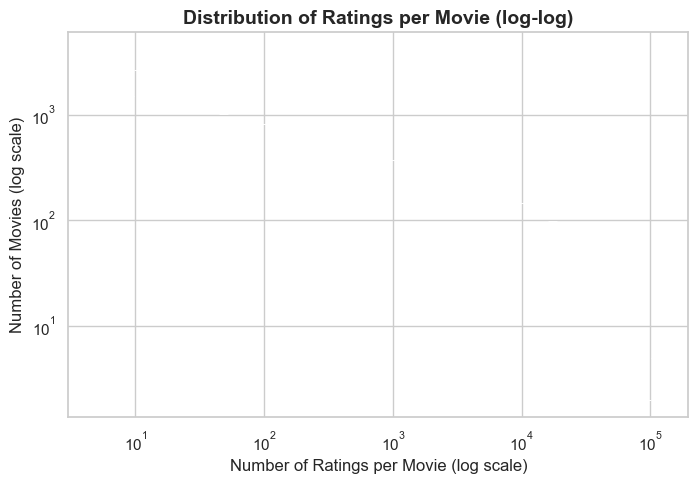

Movies with fewer than 10 ratings: 11,851 (27.0% of rated movies)
Movies with 10,000+ ratings: 838
Median ratings per movie: 23
Most-rated movie: 119,244 ratings


In [7]:
ratings_per_movie = ratings.groupby("movieId").size().rename("num_ratings")

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(ratings_per_movie, bins=60, log_scale=(True, True), color=sns.color_palette(PALETTE, 5)[2], ax=ax)
ax.set_title("Distribution of Ratings per Movie (log-log)")
ax.set_xlabel("Number of Ratings per Movie (log scale)")
ax.set_ylabel("Number of Movies (log scale)")
save_fig(fig, "movie_popularity_distribution.png")
plt.show()

n_long_tail = int((ratings_per_movie < 10).sum())
pct_long_tail = n_long_tail / len(ratings_per_movie) * 100
n_blockbuster = int((ratings_per_movie >= 10000).sum())

print(f"Movies with fewer than 10 ratings: {n_long_tail:,} ({pct_long_tail:.1f}% of rated movies)")
print(f"Movies with 10,000+ ratings: {n_blockbuster:,}")
print(f"Median ratings per movie: {ratings_per_movie.median():.0f}")
print(f"Most-rated movie: {ratings_per_movie.max():,} ratings")

**Insight:** The long tail is extreme — most of the catalog has very little rating signal, while
a small set of blockbusters absorbs a disproportionate share of attention. A recommender trained naively
will over-recommend what's already popular (it has the most training signal) and never surface the long
tail, which is exactly where personalization (NCF) and the RL layer need to add value beyond a
popularity baseline.

## 5. Genre Analysis

Three different genre questions: which genres have the most *titles* in the catalog, which get the most
*rating volume*, and which are rated *best* (weighted by rating volume, so one obscure title can't skew a
genre's average).

Saved figures\genre_movie_counts.png


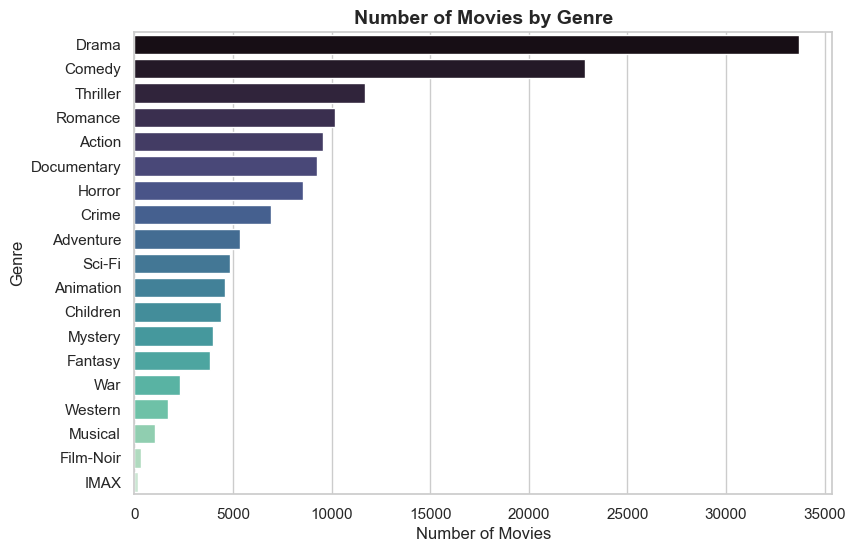

In [8]:
movie_stats = ratings.groupby("movieId").agg(num_ratings=("rating", "size"), rating_sum=("rating", "sum"))

movie_genres = movies[["movieId", "genres"]].copy()
movie_genres = movie_genres[movie_genres["genres"] != "(no genres listed)"]
movie_genres = movie_genres.assign(genre=movie_genres["genres"].str.split("|")).explode("genre")

genre_movie_counts = movie_genres.groupby("genre")["movieId"].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(
    x=genre_movie_counts.values, y=genre_movie_counts.index,
    hue=genre_movie_counts.index, palette=PALETTE, legend=False, ax=ax,
)
ax.set_title("Number of Movies by Genre")
ax.set_xlabel("Number of Movies")
ax.set_ylabel("Genre")
save_fig(fig, "genre_movie_counts.png")
plt.show()

Saved figures\genre_frequency.png


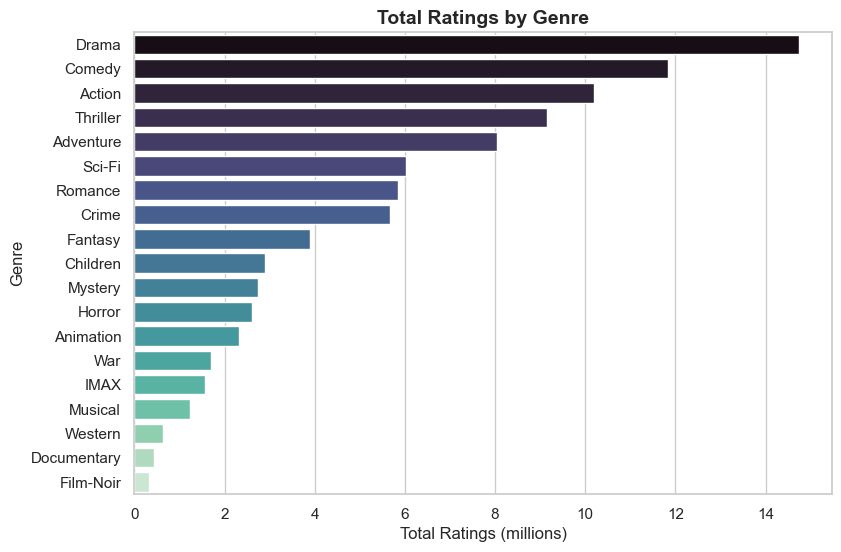

In [9]:
genre_stats = movie_genres.merge(movie_stats, on="movieId", how="inner")
genre_agg = genre_stats.groupby("genre").agg(
    total_ratings=("num_ratings", "sum"),
    rating_sum=("rating_sum", "sum"),
    num_movies=("movieId", "nunique"),
)
genre_agg["avg_rating"] = genre_agg["rating_sum"] / genre_agg["total_ratings"]
genre_agg = genre_agg.sort_values("total_ratings", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(
    x=genre_agg["total_ratings"] / 1e6, y=genre_agg.index,
    hue=genre_agg.index, palette=PALETTE, legend=False, ax=ax,
)
ax.set_title("Total Ratings by Genre")
ax.set_xlabel("Total Ratings (millions)")
ax.set_ylabel("Genre")
save_fig(fig, "genre_frequency.png")
plt.show()

Saved figures\genre_avg_rating.png


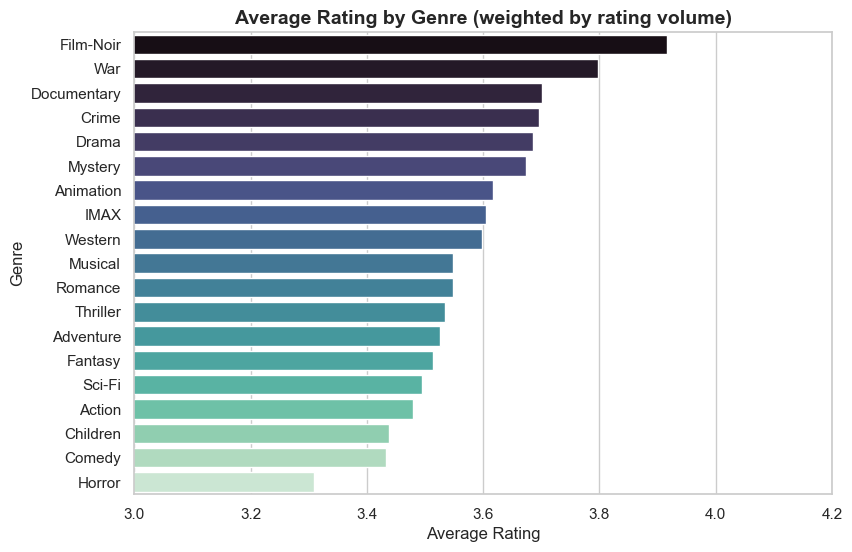

,total_ratings,rating_sum,num_movies,avg_rating
genre,,,,
Drama,14733425,54312760.0,18868,3.686363
Comedy,11826662,40596768.0,12956,3.432648
Action,10198577,35488792.0,5739,3.479779
Thriller,9146704,32327542.0,7008,3.534338
Adventure,8032576,28320856.0,3345,3.525750
Sci-Fi,6018029,21027662.0,3102,3.494111
Romance,5857092,20778444.0,5680,3.547570
Crime,5671921,20968062.0,4057,3.696818
Fantasy,3891673,13676299.0,2456,3.514247


In [10]:
genre_by_rating = genre_agg.sort_values("avg_rating", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(
    x=genre_by_rating["avg_rating"], y=genre_by_rating.index,
    hue=genre_by_rating.index, palette=PALETTE, legend=False, ax=ax,
)
ax.set_title("Average Rating by Genre (weighted by rating volume)")
ax.set_xlabel("Average Rating")
ax.set_ylabel("Genre")
ax.set_xlim(3, 4.2)
save_fig(fig, "genre_avg_rating.png")
plt.show()

genre_agg.sort_values("total_ratings", ascending=False)

**Insight:** Catalog size, rating volume, and rating quality rank genres differently — a genre
can have lots of titles without much rating volume, or high volume without a high average. High-volume
genres are safe defaults for broad recommendations; the mismatches between catalog size and rating volume
mark genres that are under- or over-represented relative to demand, which is useful context for trend
forecasting's baseline.

## 6. Temporal Trends

`ml-latest` runs from 1995 through mid-2023 — enough history to see both long-run drift and the
pandemic-era disruption to movie-watching and rating behavior.

Saved figures\monthly_rating_volume.png


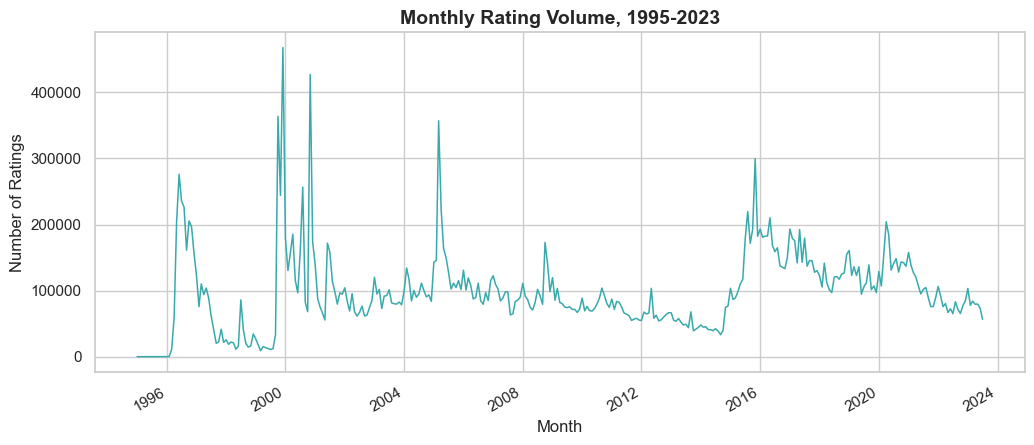

In [11]:
monthly_volume = ratings.groupby(ratings["date"].dt.to_period("M")).size()
monthly_volume.index = monthly_volume.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_volume.index, monthly_volume.values, color=sns.color_palette(PALETTE, 5)[3], linewidth=1.1)
ax.set_title("Monthly Rating Volume, 1995-2023")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Ratings")
fig.autofmt_xdate()
save_fig(fig, "monthly_rating_volume.png")
plt.show()

Saved figures\yearly_avg_rating_trend.png


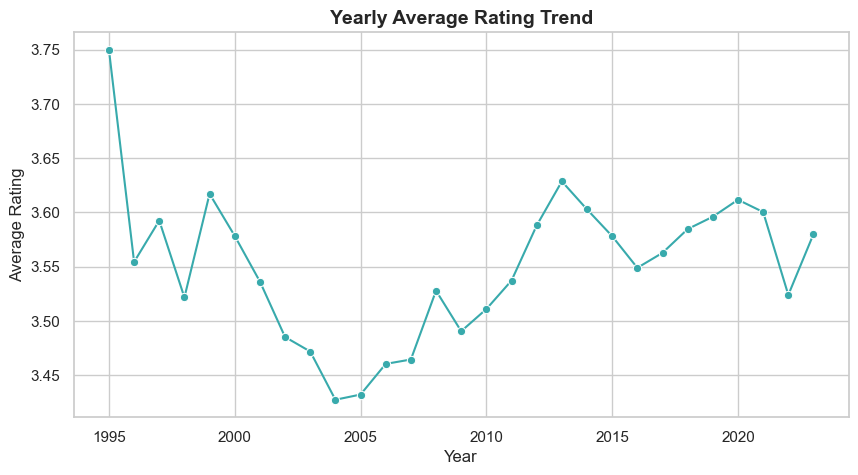

Peak activity month: 1999-12 with 467,762 ratings
Earliest year average rating: 3.75 (1995)
Latest year average rating: 3.58 (2023)


In [12]:
yearly_avg = ratings.groupby("year")["rating"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(x=yearly_avg.index, y=yearly_avg.values, marker="o", color=sns.color_palette(PALETTE, 5)[3], ax=ax)
ax.set_title("Yearly Average Rating Trend")
ax.set_xlabel("Year")
ax.set_ylabel("Average Rating")
save_fig(fig, "yearly_avg_rating_trend.png")
plt.show()

peak_month = monthly_volume.idxmax()
print(f"Peak activity month: {peak_month.strftime('%Y-%m')} with {int(monthly_volume.max()):,} ratings")
print(f"Earliest year average rating: {yearly_avg.iloc[0]:.2f} ({yearly_avg.index[0]})")
print(f"Latest year average rating: {yearly_avg.iloc[-1]:.2f} ({yearly_avg.index[-1]})")

Saved figures\covid_period_rating_volume.png


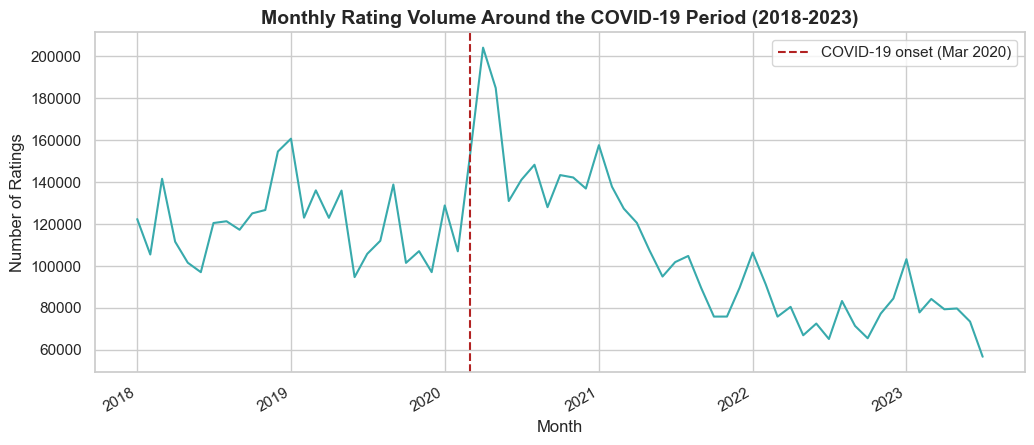

Avg monthly ratings, pre-COVID (2018-01 to 2020-02): 119,844
Avg monthly ratings, COVID period (2020-03 to 2021-12): 127,066 (+6.0% vs pre-COVID)
Avg monthly ratings, post-COVID (2022-01 onward): 78,616 (-34.4% vs pre-COVID)


In [13]:
covid_window = monthly_volume[(monthly_volume.index >= "2018-01-01")]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(covid_window.index, covid_window.values, color=sns.color_palette(PALETTE, 5)[3], linewidth=1.5)
ax.axvline(pd.Timestamp("2020-03-01"), color="firebrick", linestyle="--", linewidth=1.5, label="COVID-19 onset (Mar 2020)")
ax.set_title("Monthly Rating Volume Around the COVID-19 Period (2018-2023)")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Ratings")
ax.legend()
fig.autofmt_xdate()
save_fig(fig, "covid_period_rating_volume.png")
plt.show()

pre_covid = monthly_volume[(monthly_volume.index >= "2018-01-01") & (monthly_volume.index < "2020-03-01")].mean()
covid = monthly_volume[(monthly_volume.index >= "2020-03-01") & (monthly_volume.index < "2022-01-01")].mean()
post_covid = monthly_volume[(monthly_volume.index >= "2022-01-01")].mean()

print(f"Avg monthly ratings, pre-COVID (2018-01 to 2020-02): {pre_covid:,.0f}")
print(f"Avg monthly ratings, COVID period (2020-03 to 2021-12): {covid:,.0f} ({(covid/pre_covid - 1) * 100:+.1f}% vs pre-COVID)")
print(f"Avg monthly ratings, post-COVID (2022-01 onward): {post_covid:,.0f} ({(post_covid/pre_covid - 1) * 100:+.1f}% vs pre-COVID)")

**Insight:** Rating volume is driven far more by MovieLens's own platform history (recruitment waves,
overall decline in web-forum-era engagement) than by any single external event, and the COVID window
doesn't show a clean, isolated shock the way it did for many real-world engagement metrics. That's an
important caveat for the forecasting module: don't assume 2020-2021 is a clean natural experiment here —
platform-level trend already dominates, so any COVID feature should be validated against the pre-existing
trend, not read at face value.

## 7. Genre Trends Over Time

Aggregate genre share hides which genres are gaining or losing ground. We compute rating volume per
genre per year (via movie-level year counts joined to genre, avoiding exploding all 33M+ ratings
row-by-row) and compare each genre's early-history share of ratings to its most recent share.

Saved figures\genre_trends_over_time.png


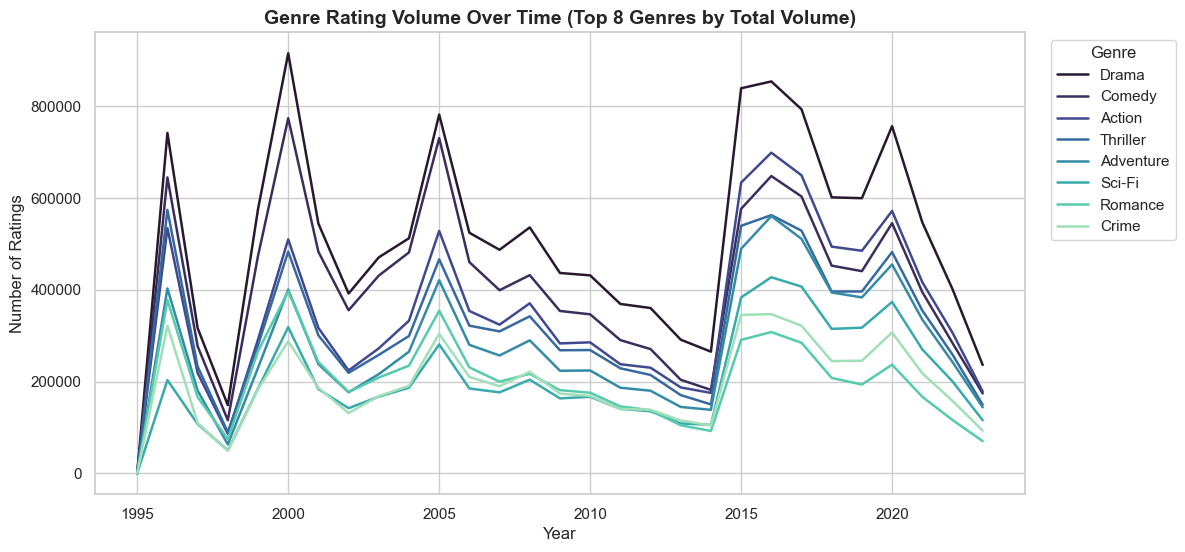

In [14]:
movie_year_counts = ratings.groupby(["movieId", "year"]).size().reset_index(name="count")
genre_year = movie_year_counts.merge(movie_genres[["movieId", "genre"]], on="movieId", how="inner")
genre_year_agg = genre_year.groupby(["year", "genre"])["count"].sum().reset_index()

top_genres = genre_agg.sort_values("total_ratings", ascending=False).head(8).index.tolist()
trend_pivot = (
    genre_year_agg[genre_year_agg["genre"].isin(top_genres)]
    .pivot(index="year", columns="genre", values="count")
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(12, 6))
palette = sns.color_palette(PALETTE, len(top_genres))
for color, genre in zip(palette, top_genres):
    ax.plot(trend_pivot.index, trend_pivot[genre], label=genre, color=color, linewidth=1.8)
ax.set_title("Genre Rating Volume Over Time (Top 8 Genres by Total Volume)")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Ratings")
ax.legend(title="Genre", bbox_to_anchor=(1.02, 1), loc="upper left")
save_fig(fig, "genre_trends_over_time.png")
plt.show()

Saved figures\genre_trend_change.png


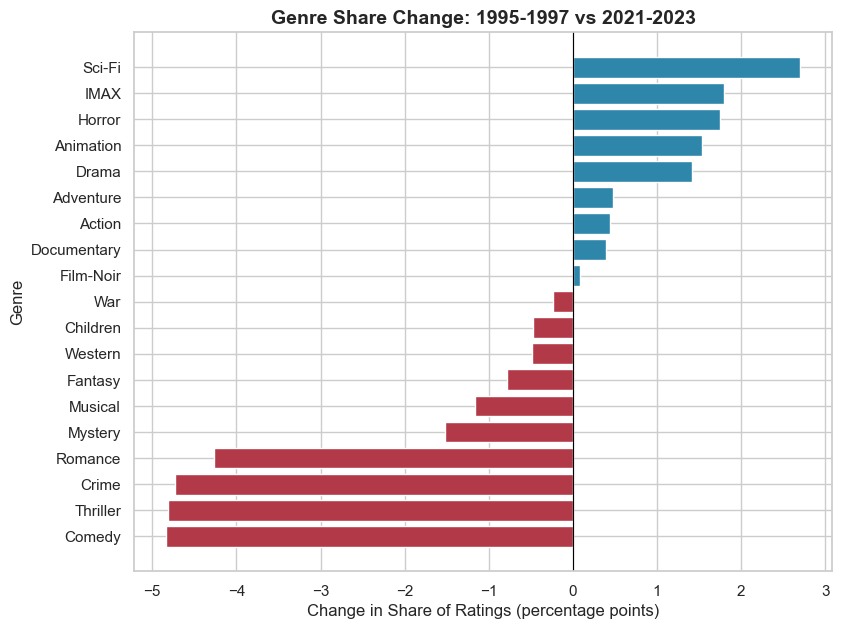

Rising genres (largest share gain):
genre
Drama        1.413142
Animation    1.533794
Horror       1.749383
IMAX         1.803135
Sci-Fi       2.703091

Declining genres (largest share loss):
genre
Comedy     -4.836050
Thriller   -4.816181
Crime      -4.727487
Romance    -4.266692
Mystery    -1.522849


In [15]:
genre_year_agg["year_total"] = genre_year_agg.groupby("year")["count"].transform("sum")
genre_year_agg["share"] = genre_year_agg["count"] / genre_year_agg["year_total"]

years_sorted = sorted(genre_year_agg["year"].unique())
early_years = years_sorted[:3]
recent_years = years_sorted[-3:]

early_share = genre_year_agg[genre_year_agg["year"].isin(early_years)].groupby("genre")["share"].mean()
recent_share = genre_year_agg[genre_year_agg["year"].isin(recent_years)].groupby("genre")["share"].mean()

trend_change = (recent_share - early_share).dropna().sort_values()
trend_change_pp = trend_change * 100

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#b23a48" if v < 0 else "#2e86ab" for v in trend_change_pp.values]
ax.barh(trend_change_pp.index, trend_change_pp.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"Genre Share Change: {early_years[0]}-{early_years[-1]} vs {recent_years[0]}-{recent_years[-1]}")
ax.set_xlabel("Change in Share of Ratings (percentage points)")
ax.set_ylabel("Genre")
save_fig(fig, "genre_trend_change.png")
plt.show()

print("Rising genres (largest share gain):")
print(trend_change_pp.tail(5).to_string())
print("\nDeclining genres (largest share loss):")
print(trend_change_pp.head(5).to_string())

**Insight:** Genre share moves meaningfully across nearly three decades of data — this
year-over-year movement is the core training signal for trend forecasting: it's what lets a LightGBM
model learn "this genre is gaining traction" as a feature-based pattern instead of forecasting each movie
in isolation.

## 8. Tags Analysis

Tags are free-text, user-contributed labels ("dark comedy", "based on a book") — a different signal than
star ratings or the curated genre list. We look at what people tag most, how tagging activity has
evolved, and which movies attract the most tags.

Saved figures\top20_tags.png


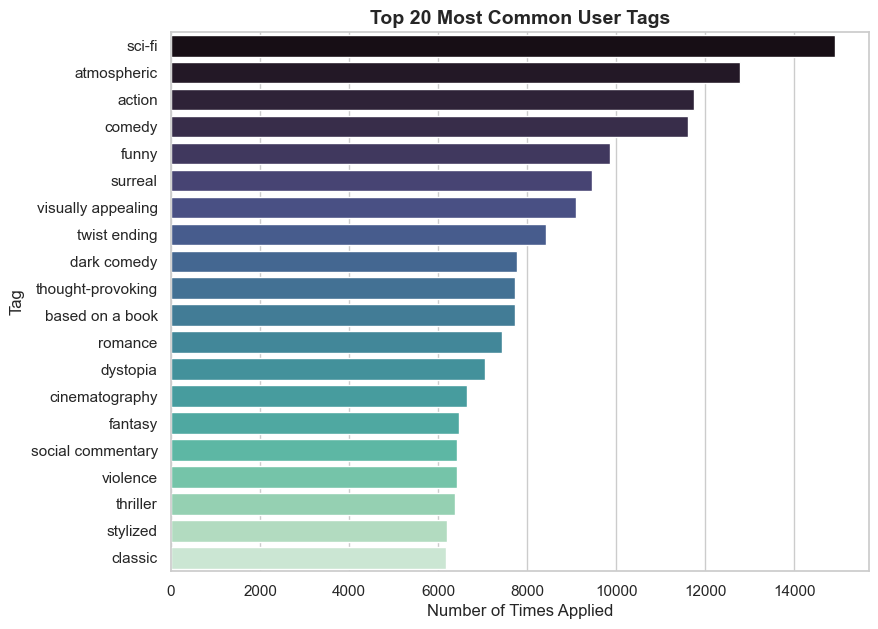

In [16]:
tags_nonnull = tags.dropna(subset=["tag"]).copy()
tag_norm = tags_nonnull["tag"].str.strip().str.lower()
top_tags = tag_norm.value_counts().head(20)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(
    x=top_tags.values, y=top_tags.index,
    hue=top_tags.index, palette=PALETTE, legend=False, ax=ax,
)
ax.set_title("Top 20 Most Common User Tags")
ax.set_xlabel("Number of Times Applied")
ax.set_ylabel("Tag")
save_fig(fig, "top20_tags.png")
plt.show()

Saved figures\tag_activity_over_time.png


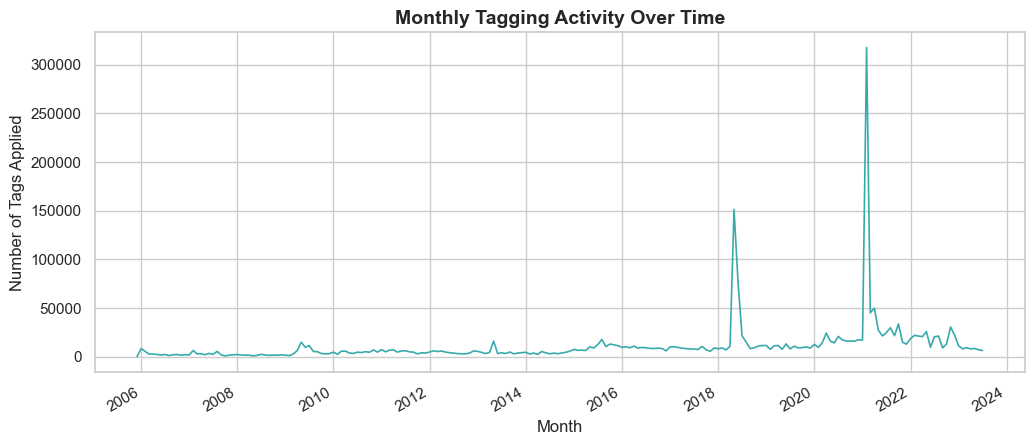

In [17]:
tag_monthly = tags_nonnull.groupby(tags_nonnull["date"].dt.to_period("M")).size()
tag_monthly.index = tag_monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(tag_monthly.index, tag_monthly.values, color=sns.color_palette(PALETTE, 5)[3], linewidth=1.2)
ax.set_title("Monthly Tagging Activity Over Time")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Tags Applied")
fig.autofmt_xdate()
save_fig(fig, "tag_activity_over_time.png")
plt.show()

Saved figures\top20_tagged_movies.png


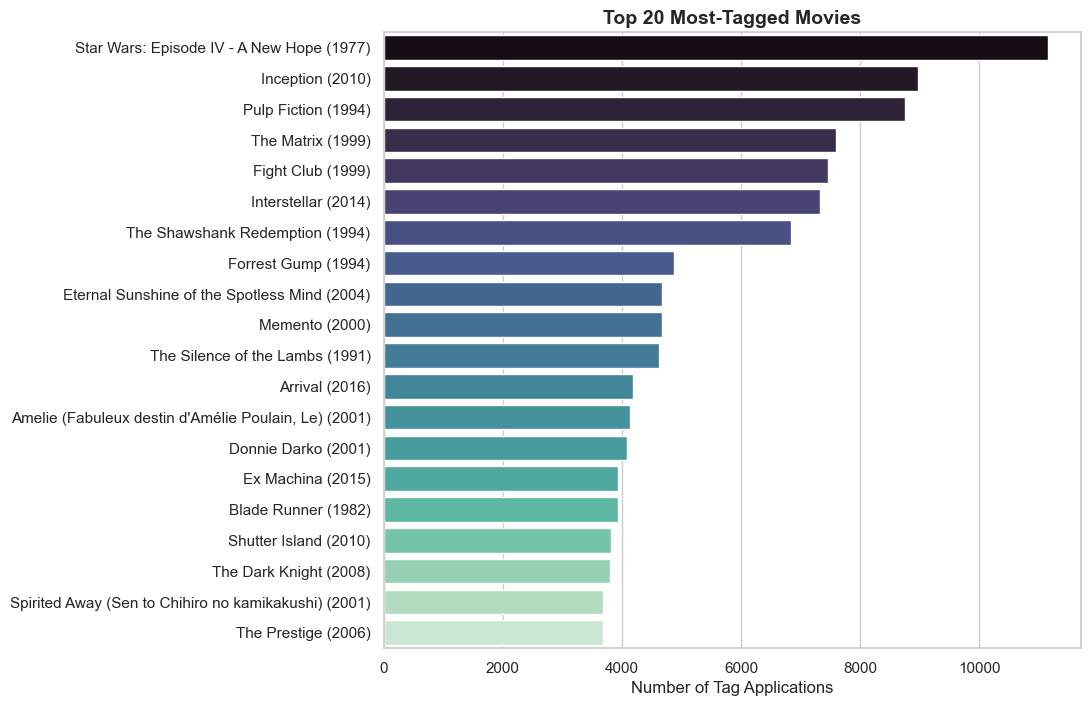

In [18]:
movie_tag_counts = tags_nonnull.groupby("movieId").size().rename("num_tags").reset_index()
top_tagged_movies = movie_tag_counts.sort_values("num_tags", ascending=False).head(20)
top_tagged_movies = top_tagged_movies.merge(movies[["movieId", "title"]], on="movieId", how="left")

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(
    x=top_tagged_movies["num_tags"], y=top_tagged_movies["title"],
    hue=top_tagged_movies["title"], palette=PALETTE, legend=False, ax=ax,
)
ax.set_title("Top 20 Most-Tagged Movies")
ax.set_xlabel("Number of Tag Applications")
ax.set_ylabel("")
save_fig(fig, "top20_tagged_movies.png")
plt.show()

**Insight:** Tags cluster around a fairly small, reusable vocabulary (recurring descriptors rather than
one-off free text), and tagging activity is far sparser than rating activity — only a fraction of users
and movies participate. That makes tags a nice qualitative supplement (raw material for the LLM
explanation layer: "tagged as darkly comedic by other viewers") but not a substitute for ratings as the
primary training signal — coverage is too thin for it to anchor the recommender or the bandit directly.

## 9. Genome Scores Analysis

The tag genome scores every movie against ~1,128 tags with a continuous relevance score (0-1), computed
by MovieLens from tags, ratings, and text mining — not just "was this tag applied." That makes it a dense,
content-based fingerprint for every scored movie, in sharp contrast to the sparse, sporadic raw tags above.

Saved figures\top20_relevant_tags.png


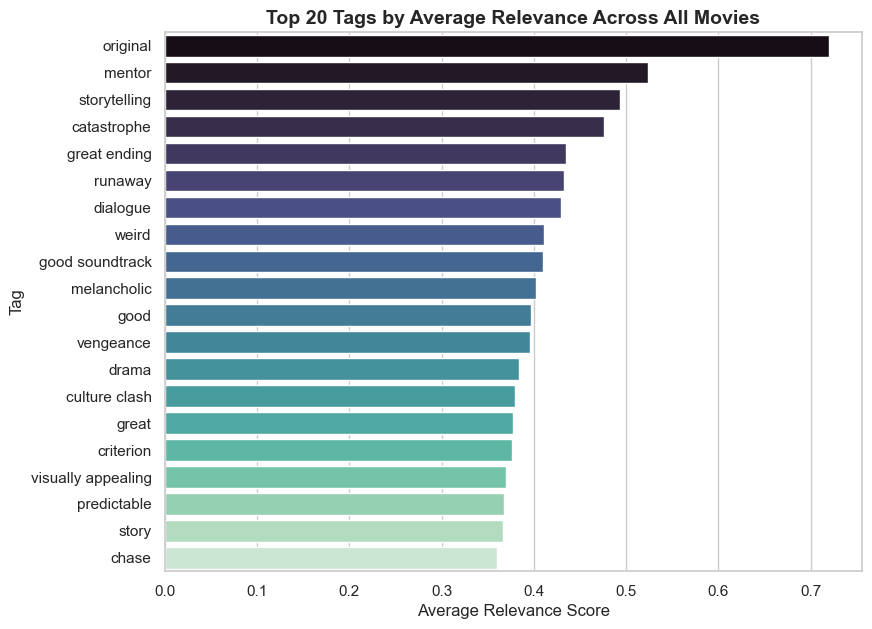

In [19]:
tag_relevance = genome_scores.groupby("tagId")["relevance"].mean().reset_index()
tag_relevance = tag_relevance.merge(genome_tags, on="tagId", how="left")
top20_relevant_tags = tag_relevance.sort_values("relevance", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(
    x=top20_relevant_tags["relevance"], y=top20_relevant_tags["tag"],
    hue=top20_relevant_tags["tag"], palette=PALETTE, legend=False, ax=ax,
)
ax.set_title("Top 20 Tags by Average Relevance Across All Movies")
ax.set_xlabel("Average Relevance Score")
ax.set_ylabel("Tag")
save_fig(fig, "top20_relevant_tags.png")
plt.show()

In [20]:
def normalize_tag(s):
    return re.sub(r"[-\s]+", " ", s.lower()).strip()

genome_tags["tag_norm"] = genome_tags["tag"].apply(normalize_tag)

key_tag_queries = ["thought provoking", "feel good", "action packed"]

for query in key_tag_queries:
    matches = genome_tags[genome_tags["tag_norm"].str.contains(query, regex=False)]
    if matches.empty:
        print(f"No genome tag found matching '{query}'")
        continue
    tag_id, tag_name = matches.iloc[0][["tagId", "tag"]]
    print(f"\nQuery '{query}' -> genome tag '{tag_name}' (tagId={tag_id})")

    top_movies = (
        genome_scores[genome_scores["tagId"] == tag_id]
        .sort_values("relevance", ascending=False)
        .head(10)
        .merge(movies[["movieId", "title"]], on="movieId", how="left")
    )
    print(top_movies[["title", "relevance"]].to_string(index=False))


Query 'thought provoking' -> genome tag 'thought-provoking' (tagId=1024)
                       title  relevance
           Ex Machina (2015)    0.93775
      The Truman Show (1998)    0.93425
                 Moon (2009)    0.92475
            Manderlay (2005)    0.92275
         Donnie Darko (2001)    0.91975
                  Her (2013)    0.91775
               Newton (2017)    0.91650
                Court (2014)    0.91100
The Parking Lot Movie (2010)    0.91050
        No Man's Land (2001)    0.90825

Query 'feel good' -> genome tag 'feel good movie' (tagId=387)
                                       title  relevance
                         Intouchables (2011)    0.97800
                      Eddie the Eagle (2016)    0.97650
                  Remember the Titans (2000)    0.97025
                  Akeelah and the Bee (2006)    0.96950
               It Could Happen to You (1994)    0.96875
                       The Blind Side (2009)    0.96875
                               

                            title  relevance
                     Speed (1994)    0.98425
         The Expendables 2 (2012)    0.98175
                  The Rock (1996)    0.98150
           Lethal Weapon 2 (1989)    0.98075
     Live Free or Die Hard (2007)    0.98000
           The Expendables (2010)    0.97950
              Broken Arrow (1996)    0.97925
Die Hard: With a Vengeance (1995)    0.97825
                  Die Hard (1988)    0.97750
                  Bad Boys (1995)    0.97725


Saved figures\genome_relevance_distribution.png


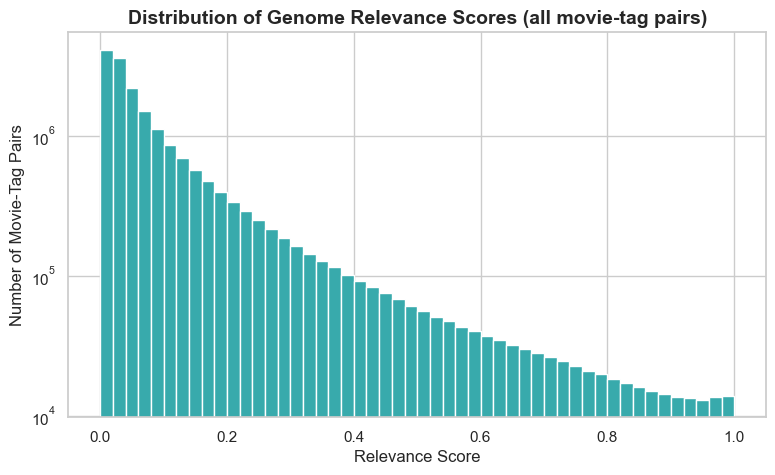

Mean relevance: 0.111


Median relevance: 0.053


% of movie-tag pairs with relevance >= 0.5: 3.6%


In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(genome_scores["relevance"], bins=50, color=sns.color_palette(PALETTE, 5)[3])
ax.set_title("Distribution of Genome Relevance Scores (all movie-tag pairs)")
ax.set_xlabel("Relevance Score")
ax.set_ylabel("Number of Movie-Tag Pairs")
ax.set_yscale("log")
save_fig(fig, "genome_relevance_distribution.png")
plt.show()

print(f"Mean relevance: {genome_scores['relevance'].mean():.3f}")
print(f"Median relevance: {genome_scores['relevance'].median():.3f}")
print(f"% of movie-tag pairs with relevance >= 0.5: {(genome_scores['relevance'] >= 0.5).mean() * 100:.1f}%")

**Insight:** Most movie-tag pairs score low (a given movie is only strongly "about" a small subset of the
~1,128 tags), which is exactly the shape a useful content fingerprint should have — it's discriminative,
not diffuse. This is a strong candidate feature source for the recommendation engine (content-based
similarity for cold-start movies with few ratings) and for the LLM layer (grounding a generated
explanation in the movie's actual highest-relevance tags rather than just its genre list).

## 10. User-Item Matrix Sparsity

The core numbers behind why collaborative filtering is hard here.

Saved figures\matrix_sparsity.png


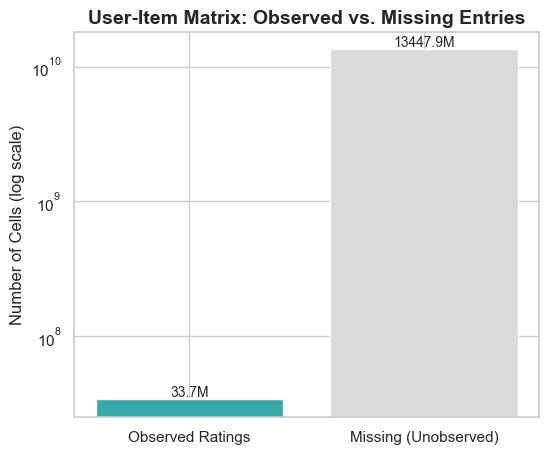

User-item matrix size: 307,412 users x 43,855 movies = 13,481,553,260 possible entries
Observed ratings: 33,703,215
Sparsity: 99.7500%  (density: 0.2500%)


In [22]:
n_users_u = ratings["userId"].nunique()
n_movies_u = ratings["movieId"].nunique()
n_possible = n_users_u * n_movies_u
n_actual = len(ratings)
sparsity = 1 - (n_actual / n_possible)
density = 1 - sparsity

fig, ax = plt.subplots(figsize=(6, 5))
bar_colors = [sns.color_palette(PALETTE, 5)[3], "#d9d9d9"]
ax.bar(["Observed Ratings", "Missing (Unobserved)"], [n_actual, n_possible - n_actual], color=bar_colors)
ax.set_title("User-Item Matrix: Observed vs. Missing Entries")
ax.set_ylabel("Number of Cells (log scale)")
ax.set_yscale("log")
for i, v in enumerate([n_actual, n_possible - n_actual]):
    ax.text(i, v, f"{v/1e6:.1f}M", ha="center", va="bottom", fontsize=10)
save_fig(fig, "matrix_sparsity.png")
plt.show()

print(f"User-item matrix size: {n_users_u:,} users x {n_movies_u:,} movies = {n_possible:,} possible entries")
print(f"Observed ratings: {n_actual:,}")
print(f"Sparsity: {sparsity*100:.4f}%  (density: {density*100:.4f}%)")

**Insight:** Over 99% sparse — the overwhelming majority of user/movie pairs have no observed
rating at all. This is the fundamental case for Neural Collaborative Filtering's learned embeddings over
lookup-table approaches, and for treating the tag genome (Section 9) as a way to give the model
*something* to go on for movies with little or no rating history.

## 11. Top Movies

Two rankings — most rated (popularity) and highest rated among movies with a credible sample size
(quality) — to see whether they're the same list.

Saved figures\top20_most_rated_movies.png


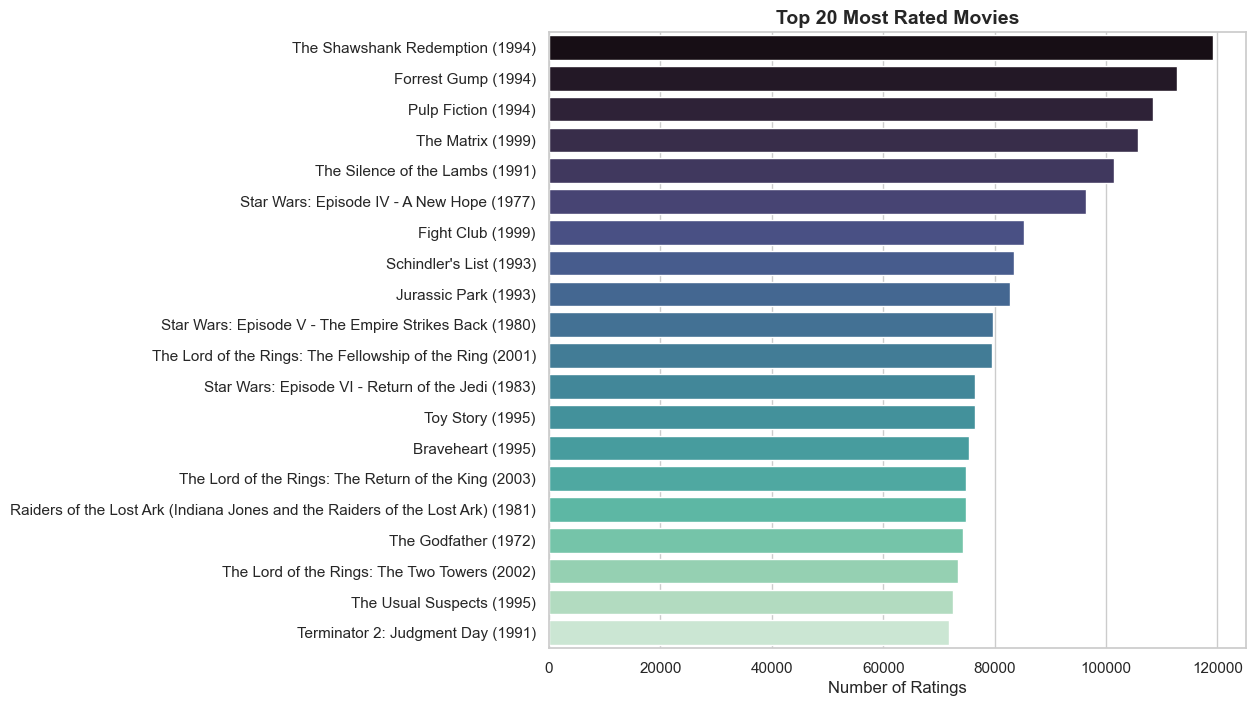

In [23]:
movie_stats_named = movie_stats.merge(movies[["movieId", "title"]], on="movieId", how="left")
movie_stats_named["avg_rating"] = movie_stats_named["rating_sum"] / movie_stats_named["num_ratings"]

top20_popular = movie_stats_named.sort_values("num_ratings", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(
    x=top20_popular["num_ratings"], y=top20_popular["title"],
    hue=top20_popular["title"], palette=PALETTE, legend=False, ax=ax,
)
ax.set_title("Top 20 Most Rated Movies")
ax.set_xlabel("Number of Ratings")
ax.set_ylabel("")
save_fig(fig, "top20_most_rated_movies.png")
plt.show()

Saved figures\top20_highest_rated_movies.png


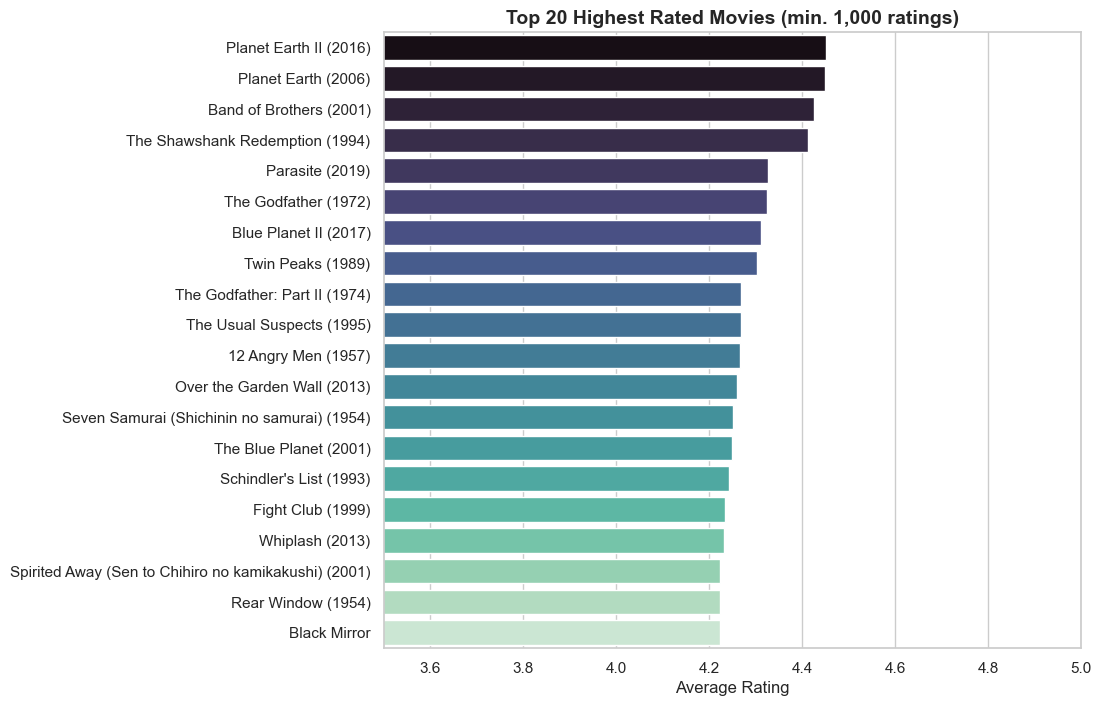

In [24]:
min_ratings_threshold = 1000
qualified = movie_stats_named[movie_stats_named["num_ratings"] >= min_ratings_threshold]
top20_quality = qualified.sort_values("avg_rating", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(
    x=top20_quality["avg_rating"], y=top20_quality["title"],
    hue=top20_quality["title"], palette=PALETTE, legend=False, ax=ax,
)
ax.set_title(f"Top 20 Highest Rated Movies (min. {min_ratings_threshold:,} ratings)")
ax.set_xlabel("Average Rating")
ax.set_ylabel("")
ax.set_xlim(3.5, 5.0)
save_fig(fig, "top20_highest_rated_movies.png")
plt.show()

Saved figures\popularity_vs_quality.png


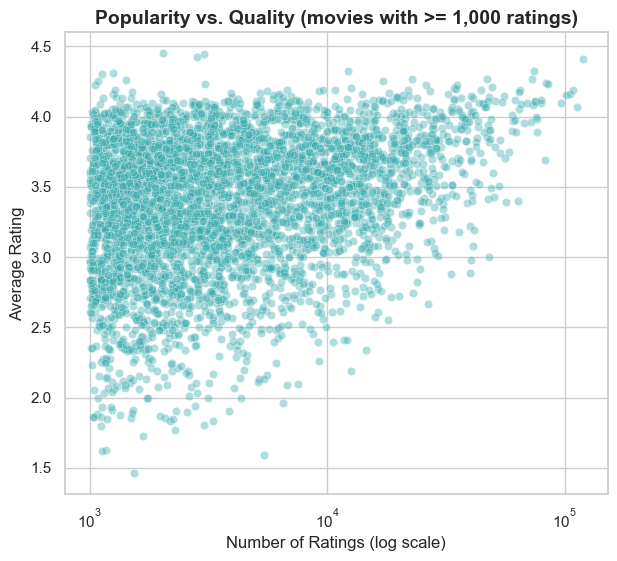

Overlap between Top 20 most-rated and Top 20 highest-rated: 5 movies
Correlation (num_ratings vs avg_rating, among movies with >= 1,000 ratings): 0.262


In [25]:
overlap = set(top20_popular["movieId"]) & set(top20_quality["movieId"])
corr = qualified["num_ratings"].corr(qualified["avg_rating"])

sample = qualified.sample(n=min(5000, len(qualified)), random_state=42)

fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(
    x=sample["num_ratings"], y=sample["avg_rating"],
    alpha=0.4, color=sns.color_palette(PALETTE, 5)[3], ax=ax,
)
ax.set_xscale("log")
ax.set_title("Popularity vs. Quality (movies with >= 1,000 ratings)")
ax.set_xlabel("Number of Ratings (log scale)")
ax.set_ylabel("Average Rating")
save_fig(fig, "popularity_vs_quality.png")
plt.show()

print(f"Overlap between Top 20 most-rated and Top 20 highest-rated: {len(overlap)} movies")
print(f"Correlation (num_ratings vs avg_rating, among movies with >= {min_ratings_threshold:,} ratings): {corr:.3f}")

**Insight:** Popularity and quality are largely different lists with only a weak correlation
between rating volume and average rating. That's a standing argument against a recommender that falls
back to "most popular" — it justifies the investment in personalization (NCF) and in an RL exploration
strategy that can surface high-quality, lower-visibility movies to the users who'd actually rate them
highly, backed by the tag genome as a way to identify *why* a lower-visibility movie might fit a given
user.

## Summary & Next Steps

- **Trend Forecasting:** Sections 6 and 7 show genre-level demand is non-stationary across nearly three
  decades, with platform-level trend dominating any single external shock (including COVID) — forecast on
  genre/time features and validate any event-based feature against the pre-existing trend.
- **Recommendation Engine:** Sections 4, 9, and 10 show extreme sparsity and popularity bias, alongside a
  lever to address it — the tag genome as a dense, content-based fingerprint that can help with
  cold-start movies where rating history alone isn't enough.
- **RL Optimization:** Sections 2 and 3 show a skewed-reward, uneven-activity pattern — segment-aware
  exploration and a reward threshold calibrated to the generous rating scale both apply directly.
- **LLM Layer:** Section 8's raw tags and Section 9's genome scores are both good raw material for
  grounding generated explanations in something more specific than genre ("scores highly on
  'thought-provoking'" beats "it's a Drama").

All figures used in this notebook are saved to `notebooks/figures/` for reuse in reports and the
dashboard.